In [13]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dataclasses import dataclass
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage
from typing import List, Annotated
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from IPython.display import display, Image
from pprint import pprint

In [14]:
@dataclass
class MyBote:
    messages: Annotated[List[AnyMessage], add_messages]

In [15]:
load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [16]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

In [17]:
def add(a: float, b: float) -> float:
    """Calculates the sum of two numbers.

    :param a: The first number to be added (addend).
    :type a: float
    :param b: The second number to be added (addend).
    :type b: float
    
    :returns: The resulting sum of the two inputs.
    :rtype: float
    
    .. code-block:: python

        # Example Usage with doctest format
        >>> add(3, 6)
        9.0
        >>> add(2.1, 1.3)
        3.4
    """
    return a + b




In [18]:
llm_bind = llm.bind_tools([add])

In [19]:
def llmTool(state: MyBote):

    return {"messages": [llm_bind.invoke(state.messages)]}

In [20]:
graph = StateGraph(MyBote)

graph.add_node("llmTool",llmTool)

graph.add_edge(START, "llmTool")
graph.add_edge("llmTool", END)

graph_builder = graph.compile()

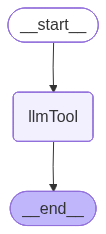

In [21]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [22]:
result = graph_builder.invoke(MyBote(messages="What is 2 plus 3"))

for item in result['messages']:
    print(item.model_dump_json())

{"content":"What is 2 plus 3","additional_kwargs":{},"response_metadata":{},"type":"human","name":null,"id":"c539450d-4f8e-4910-a99d-ec854c0e353b"}
{"content":"","additional_kwargs":{"reasoning_content":"User asks: \"What is 2 plus 3\". Simple addition. Could answer directly: 5. Or use function add. Use function.","tool_calls":[{"id":"fc_78c31049-6fac-4191-ac35-02ede7f742c9","function":{"arguments":"{\"a\":2,\"b\":3}","name":"add"},"type":"function"}]},"response_metadata":{"token_usage":{"completion_tokens":64,"prompt_tokens":237,"total_tokens":301,"completion_time":0.137251248,"completion_tokens_details":{"reasoning_tokens":31},"prompt_time":0.00970191,"prompt_tokens_details":null,"queue_time":0.003972353,"total_time":0.146953158},"model_name":"openai/gpt-oss-120b","system_fingerprint":"fp_4867cb64c5","service_tier":"on_demand","finish_reason":"tool_calls","logprobs":null,"model_provider":"groq"},"type":"ai","name":null,"id":"lc_run--f6eee3d6-3fec-499b-b4b8-50ca05f502d7-0","tool_calls

In [24]:
result = graph_builder.invoke(MyBote(messages="What is LLM"))

for item in result['messages']:
    print(item.model_dump_json())

{"content":"What is LLM","additional_kwargs":{},"response_metadata":{},"type":"human","name":null,"id":"f7a279b7-9674-42f6-8360-732c8fa48222"}
{"content":"**LLM = Large Language Model**\n\nA *large language model* (LLM) is a type of artificial‑intelligence system that learns to predict and generate human‑like text. It does this by being trained on massive collections of written language (books, articles, code, web pages, etc.) and by using deep neural‑network architectures—most commonly the **Transformer**—that can capture complex patterns across long sequences of words.\n\n---\n\n### Core Characteristics\n\n| Feature | What It Means |\n|---------|----------------|\n| **Scale** | “Large” refers to two things: (1) **parameter count** – often billions to trillions of learnable weights, and (2) **training data size** – billions of tokens (words/sub‑words). |\n| **Generative** | Given a prompt, the model produces the next token(s) one at a time, effectively “writing” sentences, code, or ot